In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=c79f84e7a8a91a65566da8ed872b6e8424ef8a53d8a30c1aaa3475d8a9111d81
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


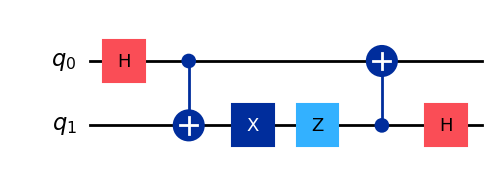

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [ ]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

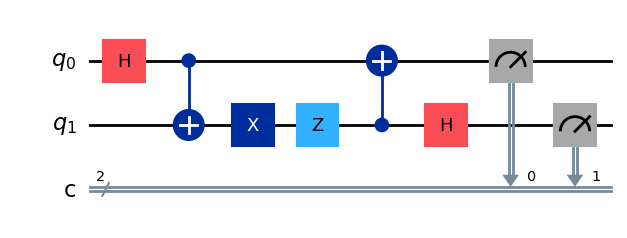

In [6]:
import qiskit_aer
from qiskit.circuit import ClassicalRegister # Import ClassicalRegister

# Create a copy of the circuit to add measurements without modifying the original
sdc_measured = sdc.copy_empty_like()

# Add the quantum gates from the original circuit
sdc_measured.compose(sdc, inplace=True)

# Create a classical register with 2 bits
cr = ClassicalRegister(2, name='c')

# Add the classical register to the circuit
sdc_measured.add_register(cr)

# Measure both qubits into the classical bits
sdc_measured.measure([0, 1], cr)

sdc_measured.draw('mpl')

Now, let's simulate this circuit and look at the measurement results.

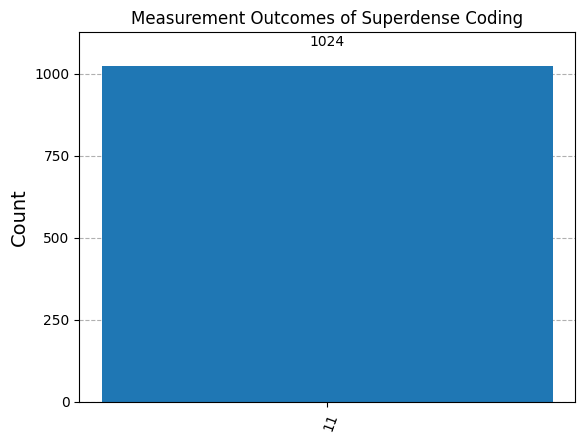

In [8]:
# Select the AerSimulator
simulator = qiskit_aer.AerSimulator()

# Transpile the circuit for the simulator
transpiled_circuit = transpile(sdc_measured, simulator)

# Run the simulation
job = simulator.run(transpiled_circuit, shots=1024)

# Get the result
result = job.result()

# Get the counts (measurement statistics) for the single experiment
counts = result.get_counts() # Removed argument for single experiment

# Plot the histogram
plot_histogram(counts, title='Measurement Outcomes of Superdense Coding')

In [ ]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

### Superdense Coding with Conditional Gates

This implementation will encode two classical bits (`b1b0`) using conditional X and Z gates applied by Alice. For demonstration, we'll encode `11` as an example.

Here, `b1` will control the Z gate and `b0` will control the X gate on Alice's qubit.

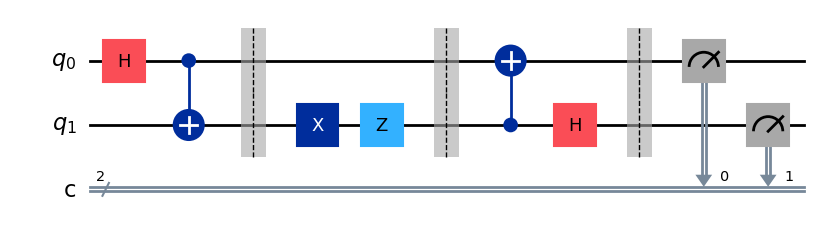

In [11]:
from qiskit import QuantumCircuit, ClassicalRegister, transpile # Corrected transpile import
import qiskit_aer
from qiskit.visualization import plot_histogram

# Define the classical bits to be encoded by Alice (e.g., '11')
b1 = 1 # Most significant bit (controls Z gate)
b0 = 1 # Least significant bit (controls X gate)

# Create a new quantum circuit for this implementation
sdc_conditional = QuantumCircuit(2, 2) # 2 qubits, 2 classical bits

# Step 1: Initialize the entangled state (Bell state |phi+>)
sdc_conditional.h(0)
sdc_conditional.cx(0, 1)

sdc_conditional.barrier()

# Step 2: Alice's Encoding based on classical bits
# Alice has qubit 1, Bob has qubit 0 (as per the previous example's entanglement)

# Apply X gate on Alice's qubit (qubit 1) if b0 is 1
if b0 == 1:
    sdc_conditional.x(1)

# Apply Z gate on Alice's qubit (qubit 1) if b1 is 1
if b1 == 1:
    sdc_conditional.z(1)

sdc_conditional.barrier()

# Step 3: Bob's Decoding
sdc_conditional.cx(1, 0)
sdc_conditional.h(1)

sdc_conditional.barrier()

# Step 4: Measurements
sdc_conditional.measure([0, 1], [0, 1])

sdc_conditional.draw('mpl')

Now, let's simulate this circuit and check the measurement results. We expect the outcome to be `b1b0` (e.g., `11` for this example).

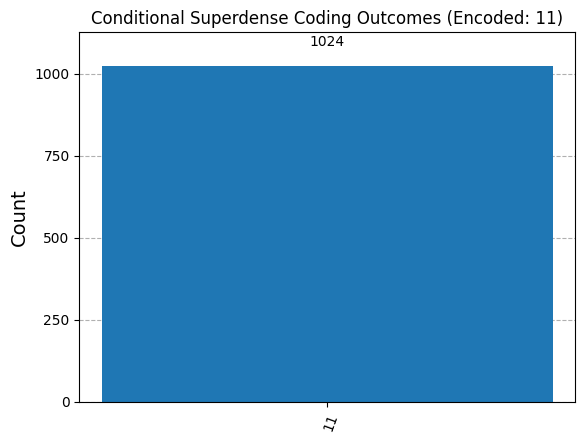

In [12]:
# Select the AerSimulator
simulator = qiskit_aer.AerSimulator()

# Transpile the circuit for the simulator
transpiled_circuit_cond = transpile(sdc_conditional, simulator)

# Run the simulation
job_cond = simulator.run(transpiled_circuit_cond, shots=1024)

# Get the result
result_cond = job_cond.result()

# Get the counts (measurement statistics)
counts_cond = result_cond.get_counts()

# Plot the histogram
plot_histogram(counts_cond, title=f'Conditional Superdense Coding Outcomes (Encoded: {b1}{b0})')

As you can see from the histogram, the most frequent measurement outcome matches the `b1b0` value that Alice encoded. You can modify the `b1` and `b0` variables in the encoding cell to experiment with other classical bit pairs (00, 01, 10) and re-run the cells to observe the corresponding measurement outcomes.